In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

In [3]:

comb_numt_df = pd.DataFrame()

for sample in df_pb['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])

for sample in df_ont['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])


comb_numt_df[['nchr', 'npos']] = comb_numt_df['qseqid'].str.split('-', expand=True)
comb_numt_df['npos'] = np.where(comb_numt_df['qstart'].astype(int) > 1, comb_numt_df['npos'].astype(int) + comb_numt_df['qstart'].astype(int) - 1, comb_numt_df['npos'].astype(int))
comb_numt_df['id'] = comb_numt_df['nchr'] + "-" + comb_numt_df['npos'].astype(str)
comb_numt_df = comb_numt_df[comb_numt_df['nchr'] != 'chrM']
comb_numt_df['mstart'] = np.where(comb_numt_df['sstart'].astype(int) < comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))
comb_numt_df['mend'] = np.where(comb_numt_df['sstart'].astype(int) >= comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))

comb_numt_df = comb_numt_df[['qseqid', 'id', 'nchr', 'npos', 'length', 'mstart', 'mend', 'Sample']]

comb_numt_df[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = comb_numt_df['Sample'].str.split('-', expand=True)
comb_numt_df['Donor+Tissue'] = comb_numt_df['Donor'] + "_" + comb_numt_df['Tissue']

comb_numt_df


,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue
0,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON
1,chr1-54625173,chr1-54625173,chr1,54625173,41,1573,1613,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON
2,chr2-33667411,chr2-33667416,chr2,33667416,246,14777,15022,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON
3,chr4-86138984,chr4-86138984,chr4,86138984,47,6170,6216,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON
4,chr5-144790242,chr5-144790242,chr5,144790242,329,15178,15506,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,chr5-32338477,chr5-32338477,chr5,32338477,147,14831,14977,ST001-1A_LIVER-ont-uwsc,ST001,1A_LIVER,ont,uwsc,None,ST001_1A_LIVER
5,chr5-32338477,chr5-32338624,chr5,32338624,133,12735,12867,ST001-1A_LIVER-ont-uwsc,ST001,1A_LIVER,ont,uwsc,None,ST001_1A_LIVER
6,chr11-4635113,chr11-4635113,chr11,4635113,40,16423,16462,ST001-1A_LIVER-ont-uwsc,ST001,1A_LIVER,ont,uwsc,None,ST001_1A_LIVER
7,chr11-49862017,chr11-49862017,chr11,49862017,60,1,60,ST001-1A_LIVER-ont-uwsc,ST001,1A_LIVER,ont,uwsc,None,ST001_1A_LIVER


In [4]:
# tolerance = 25

# df = comb_numt_df.sort_values(
#     ['nchr', 'npos', 'mstart', 'mend']
# ).reset_index(drop=True)

# # Bin coordinates by tolerance
# df['npos_bin']   = (df['npos']   // tolerance) * tolerance
# df['length_bin'] = (df['length'] // tolerance) * tolerance
# df['mstart_bin'] = (df['mstart'] // tolerance) * tolerance
# df['mend_bin']   = (df['mend']   // tolerance) * tolerance

# # Assign NUMT IDs
# df['NUMT_ID'] = (
#     df.groupby(
#         ['nchr', 'npos_bin', 'length_bin', 'mstart_bin', 'mend_bin']
#     )
#     .ngroup()
#     .add(1)
#     .map(lambda x: f"NUMT_{x}")
# )

# # Optional: drop helper columns
# #df = df.drop(columns=['npos_bin', 'length_bin', 'mstart_bin', 'mend_bin'])

# rep_cols = {
#     'npos':   'npos_rep',
#     'length':'length_rep',
#     'mstart':'mstart_rep',
#     'mend':  'mend_rep'
# }

# for col, new_col in rep_cols.items():
#     df[new_col] = (
#         df.groupby('NUMT_ID')[col]
#           .transform('median')
#           .astype(int)
#     )

# df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)


# df

In [5]:
tolerance = 25

df = comb_numt_df.sort_values(
    ['nchr', 'npos', 'mstart', 'mend']
).reset_index(drop=True)

numt_ids = [None] * len(df)
current_id = 1

for i in range(len(df)):
    if numt_ids[i] is not None:
        continue

    numt_ids[i] = f"NUMT_{current_id}"
    current = df.iloc[i]

    # grow cluster forward
    for j in range(i + 1, len(df)):
        row = df.iloc[j]

        if row['nchr'] != current['nchr']:
            break  # sorted by chr

        if abs(row['npos'] - df.loc[i, 'npos']) > tolerance:
            break  # window exceeded

        if (
            abs(row['length'] - current['length']) <= tolerance and
            abs(row['mstart'] - current['mstart']) <= tolerance and
            abs(row['mend'] - current['mend']) <= tolerance
        ):
            numt_ids[j] = f"NUMT_{current_id}"

    current_id += 1

df['NUMT_ID'] = numt_ids

rep_cols = {
    'npos':   'npos_rep',
    'length':'length_rep',
    'mstart':'mstart_rep',
    'mend':  'mend_rep'
}

for col, new_col in rep_cols.items():
    df[new_col] = (
        df.groupby('NUMT_ID')[col]
          .transform('median')
          .astype(int)
    )

df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)


df

,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
0,chr1-37611748,chr1-37611748,chr1,37611748,71,8935,9005,ST002-1G_COLON-ont-uwsc,ST002,1G_COLON,ont,uwsc,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
1,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1G_COLON-pacbio-washu,ST002,1G_COLON,pacbio,washu,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
2,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
3,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1D_LUNG-pacbio-bcm,ST002,1D_LUNG,pacbio,bcm,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
4,chr1-37611748,chr1-37611748,chr1,37611748,72,8935,9006,ST002-1G_COLON-pacbio-broad,ST002,1G_COLON,pacbio,broad,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-pacbio-washu,ST003,1Q_BRAIN,pacbio,washu,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
373,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-pacbio-broad,ST003,1Q_BRAIN,pacbio,broad,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
374,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-ont-uwsc,ST003,1Q_BRAIN,ont,uwsc,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420
375,chr9-129766,chr9-129776,chr9,129776,195,6226,6420,ST003-1Q_BRAIN-ont-nygc,ST003,1Q_BRAIN,ont,nygc,None,ST003_1Q_BRAIN,NUMT_22,129776,195,6226,6420,chr9_129776_195_6226_6420


In [6]:

high_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) > 1)
high_conf_numts


low_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) == 1)
low_conf_numts

,qseqid,id,nchr,npos,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
46,chr1-230505699,chr1-230505758,chr1,230505758,1457,2489,3932,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_3,230505758,1457,2489,3932,chr1_230505758_1457_2489_3932
167,chr14-25947180,chr14-25947180,chr14,25947180,38,5781,5818,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_9,25947180,38,5781,5818,chr14_25947180_38_5781_5818
244,chr22-40620124,chr22-40620124,chr22,40620124,1020,3252,4269,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_13,40620124,1020,3252,4269,chr22_40620124_1020_3252_4269
245,chr22-40620124,chr22-40621136,chr22,40621136,1414,3240,4649,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_14,40621136,1414,3240,4649,chr22_40621136_1414_3240_4649
356,chr7-115030581,chr7-115030582,chr7,115030582,5287,3218,8492,ST004-1Q_BRAIN-pacbio-uwsc,ST004,1Q_BRAIN,pacbio,uwsc,None,ST004_1Q_BRAIN,NUMT_20,115030582,5287,3218,8492,chr7_115030582_5287_3218_8492
376,chrX-111421052,chrX-111422220,chrX,111422220,40,3036,3075,ST004-1Q_BRAIN-ont-uwsc,ST004,1Q_BRAIN,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_23,111422220,40,3036,3075,chrX_111422220_40_3036_3075


In [7]:
def custom_join(series):
    return ','.join(series.astype(str))

collapsed_numt_df = high_conf_numts.groupby(['numt_long', 'length_rep', 'Donor', 'Tissue']).agg(
        reps=('numt_long', 'count'), rep_names=('Sample', custom_join)).reset_index()

collapsed_numt_df['Donor_Tissue'] = collapsed_numt_df['Donor'] + "-" + collapsed_numt_df['Tissue']

collapsed_numt_df

,numt_long,length_rep,Donor,Tissue,reps,rep_names,Donor_Tissue
0,chr11_100145018_59_11499_11557,59,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi...",ST001-1A_LIVER
1,chr11_100145018_59_11499_11557,59,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG
2,chr11_100145018_59_11499_11557,59,ST002,1D_LUNG,8,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
3,chr11_100145018_59_11499_11557,59,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-washu,ST002-1G_COLON-pac...",ST002-1G_COLON
4,chr11_4635113_40_16423_16462,40,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi...",ST001-1A_LIVER
5,chr11_4635113_40_16423_16462,40,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-broad,ST001-1D_LUNG-pacbi...",ST001-1D_LUNG
6,chr11_4635113_40_16423_16462,40,ST002,1D_LUNG,8,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
7,chr11_4635113_40_16423_16462,40,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-washu,ST002-1G_COLON-pac...",ST002-1G_COLON
8,chr11_4635113_40_16423_16462,40,ST003,1Q_BRAIN,6,"ST003-1Q_BRAIN-pacbio-uwsc,ST003-1Q_BRAIN-pacb...",ST003-1Q_BRAIN
9,chr11_4635113_40_16423_16462,40,ST004,1Q_BRAIN,6,"ST004-1Q_BRAIN-pacbio-uwsc,ST004-1Q_BRAIN-pacb...",ST004-1Q_BRAIN


In [16]:
counts = (
    collapsed_numt_df.groupby("Donor_Tissue", as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)
# counts = pd.merge(counts, df[['Sample', 'Mito_Read_Count', 'Age']], on='Sample')
#counts[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = counts['Sample'].str.split('-', expand=True)
#counts['Donor+Tissue'] = counts['Donor'] + "_" + counts['Tissue']

counts

,Donor_Tissue,count
0,ST001-1A_LIVER,10
1,ST001-1D_LUNG,10
2,ST002-1D_LUNG,11
3,ST002-1G_COLON,10
4,ST003-1Q_BRAIN,7
5,ST004-1Q_BRAIN,9


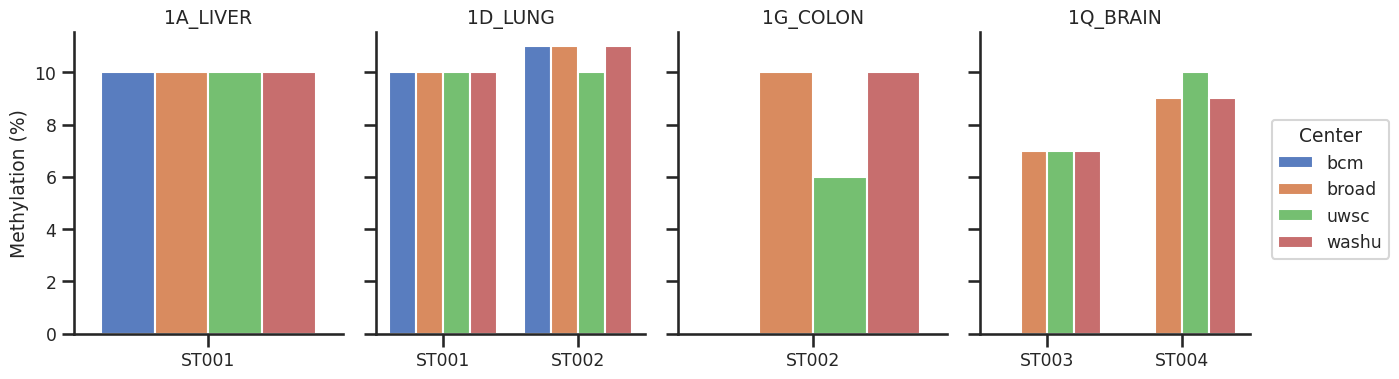

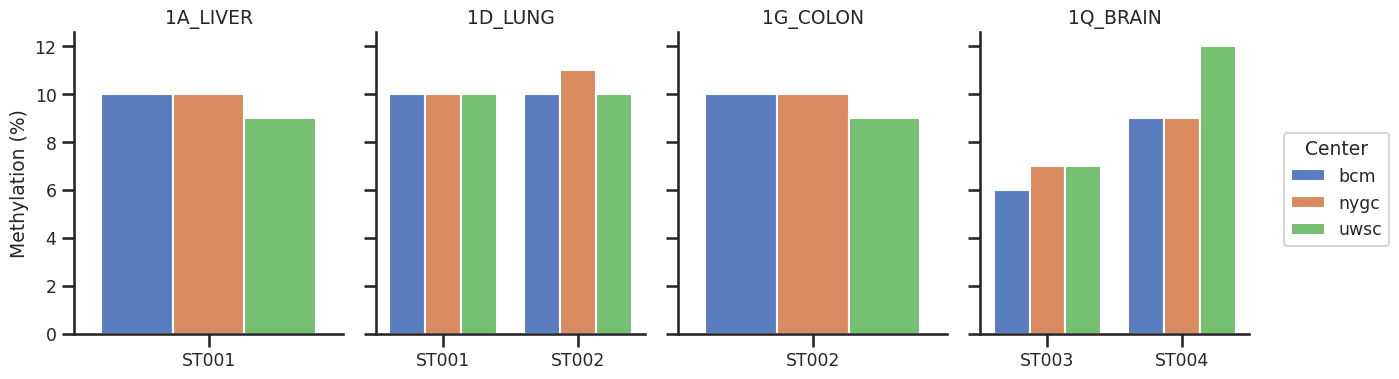

In [9]:
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

g = sns.catplot(
    data=counts[counts['Seq_Tech'] == 'pacbio'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=counts[counts['Seq_Tech'] == 'ont'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

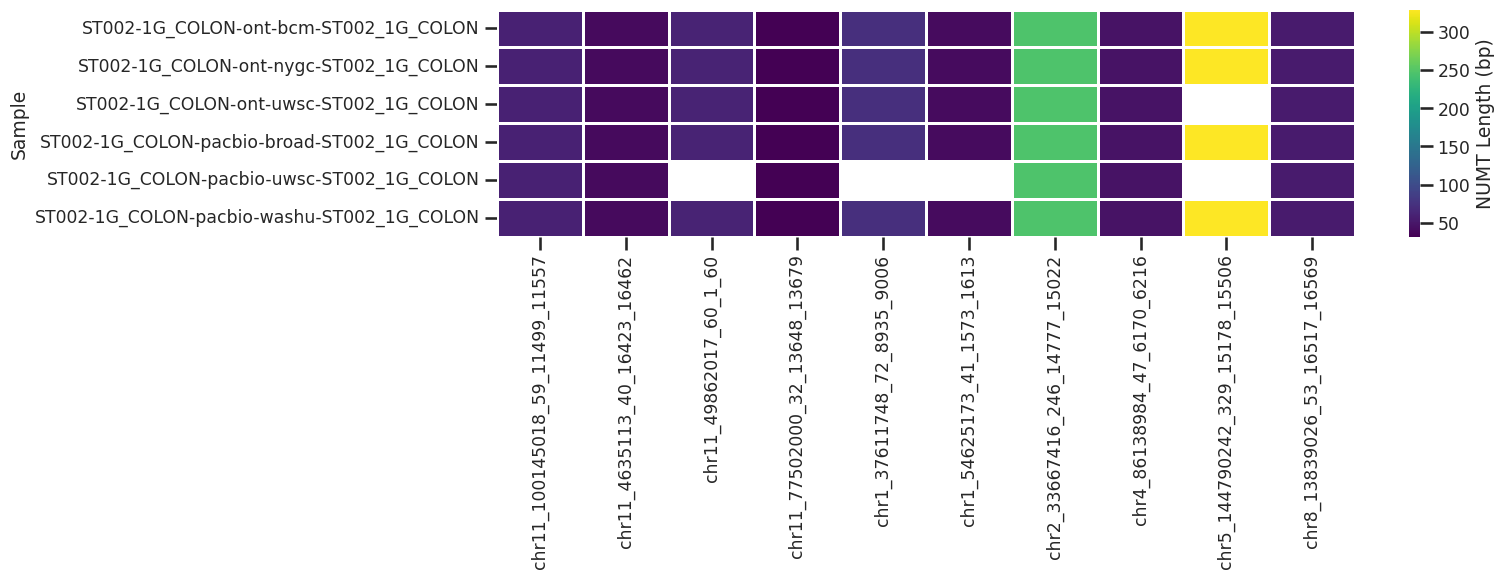

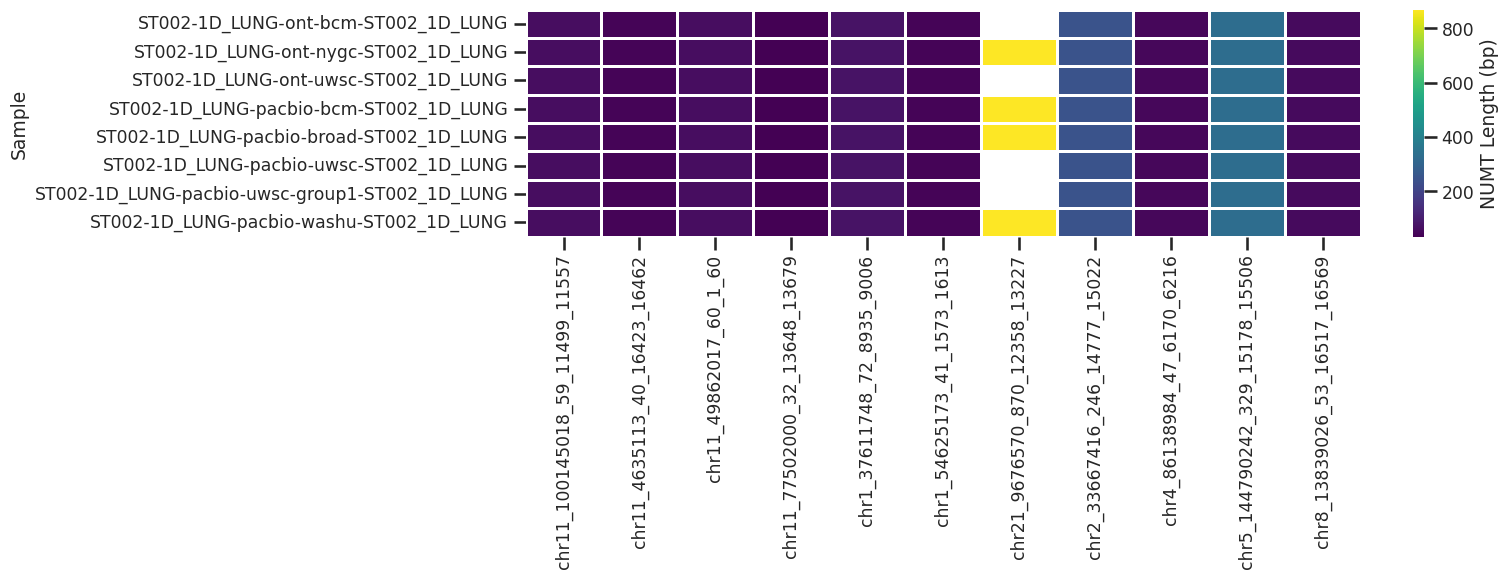

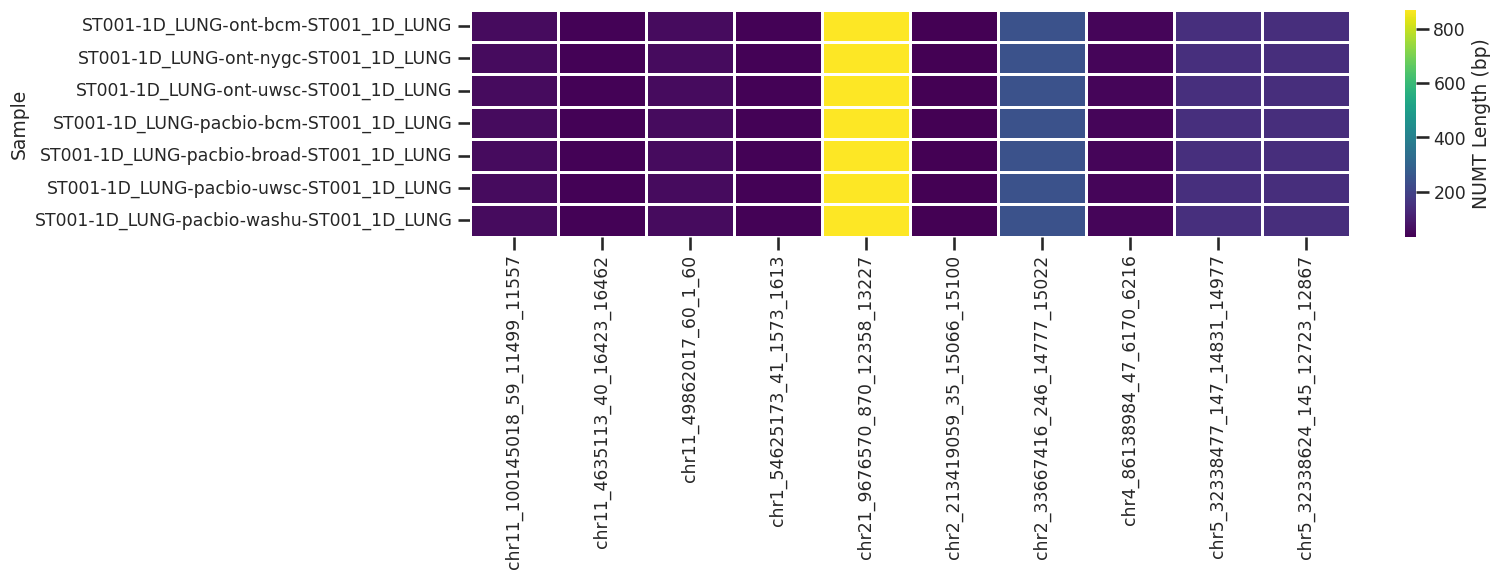

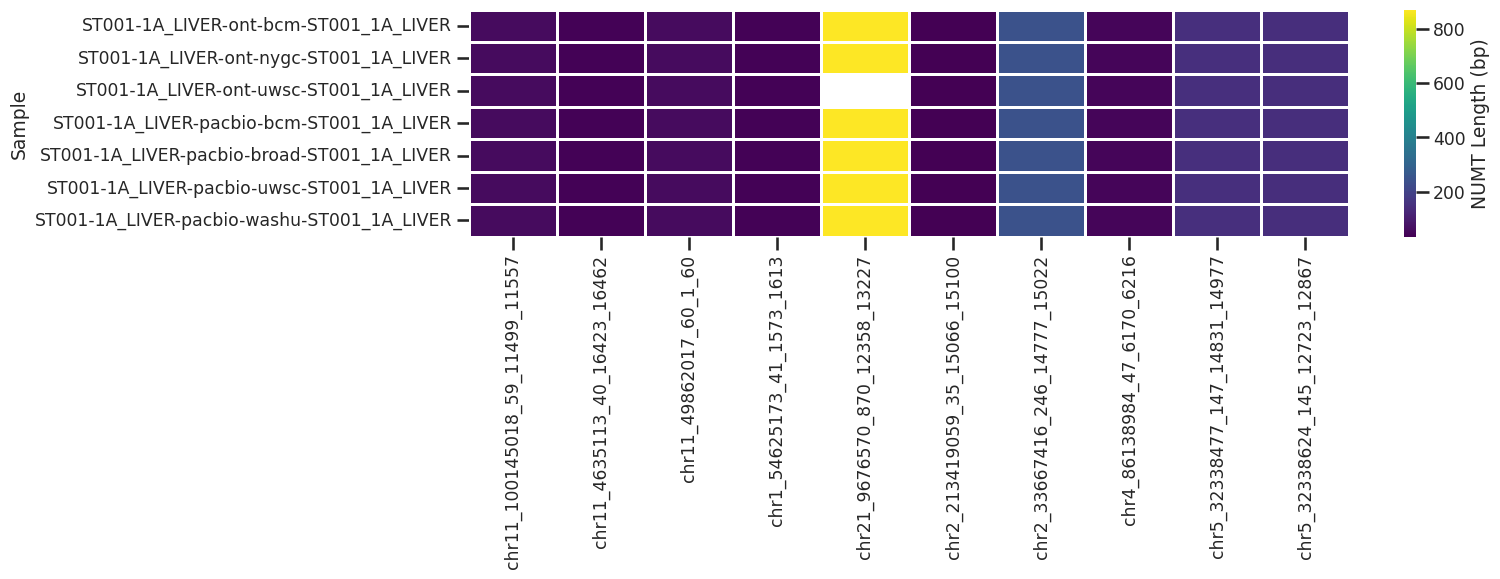

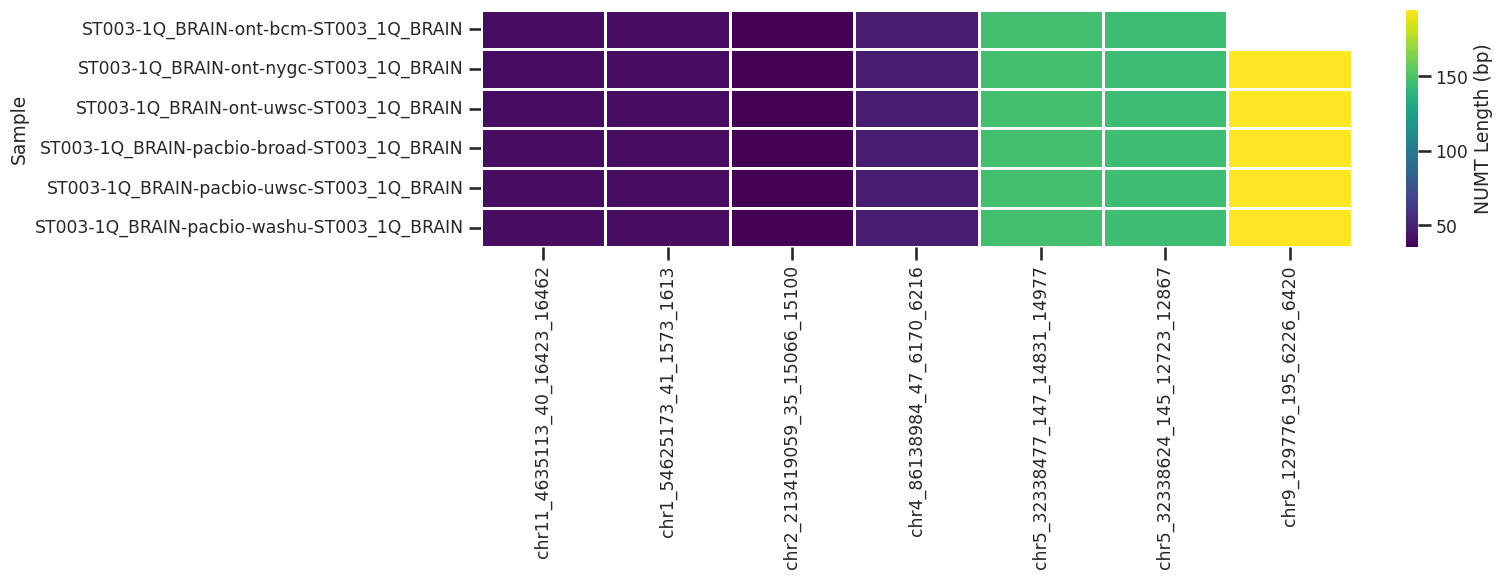

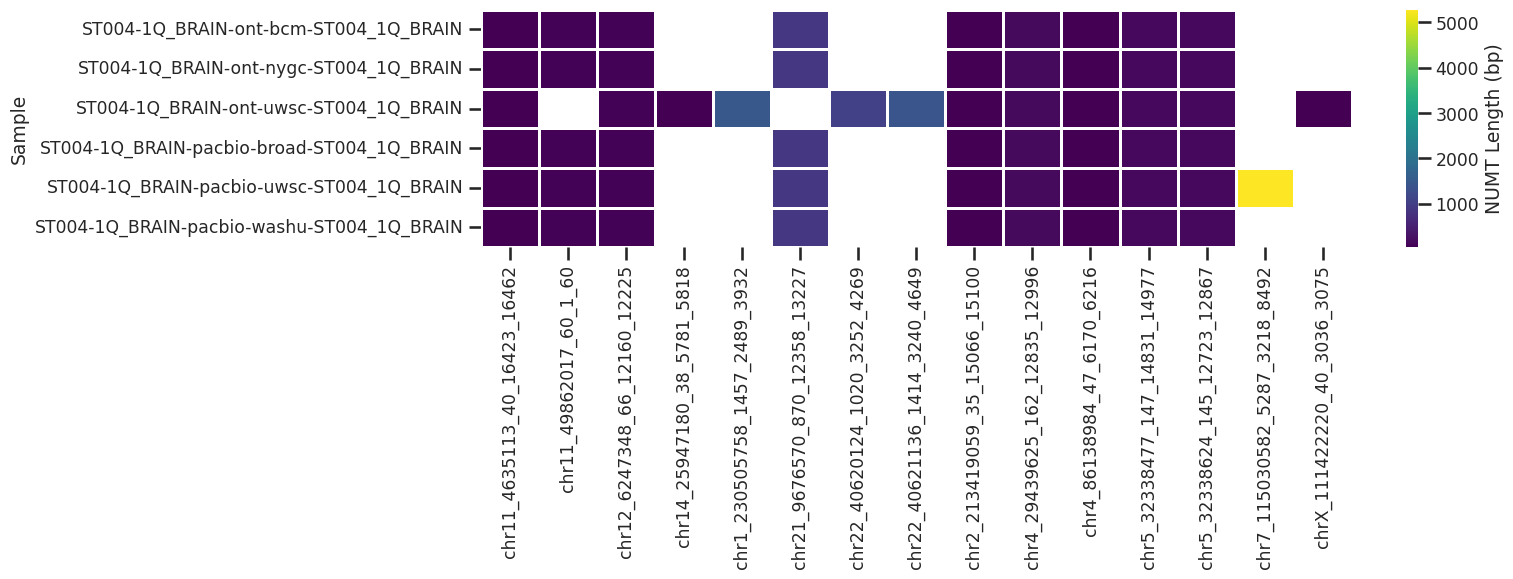

In [10]:

donors = ['ST001', 'ST002', 'ST003', 'ST004']

for d in df['Donor+Tissue'].unique():

    heatmap_data = df[df['Donor+Tissue'] == d].pivot(index=['Sample','Donor+Tissue'], columns='numt_long', values='length_rep')

    # Sort columns by chrom
    #column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    #heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'NUMT Length (bp)'})
    plt.title('')
    plt.xlabel('')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()


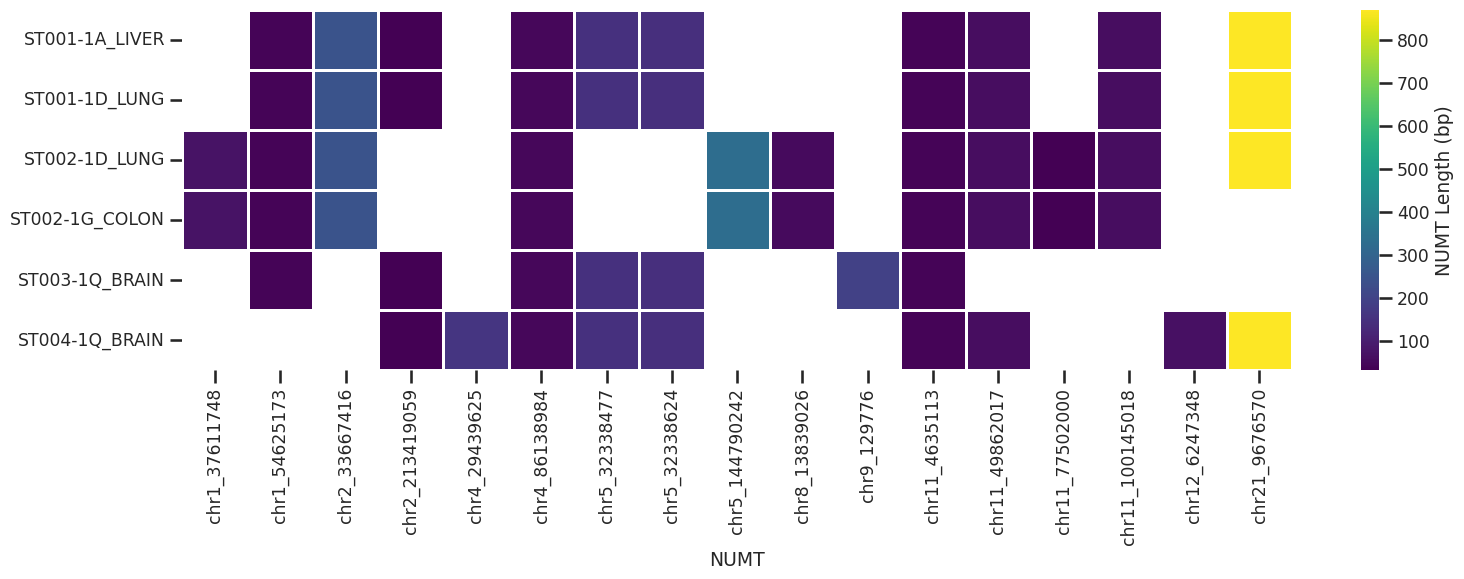

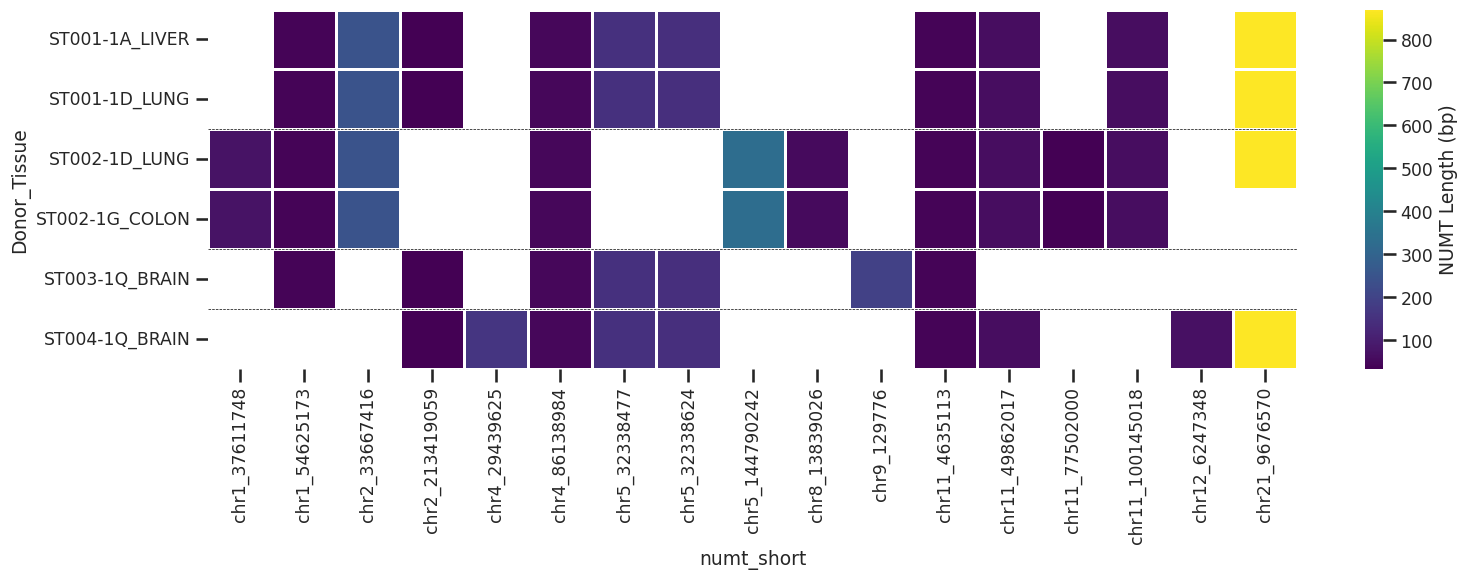

In [11]:

collapsed_numt_df[['nchr', 'npos_rep', 'length_rep2', 'mstart_rep', 'mend_rep']] = collapsed_numt_df['numt_long'].str.split('_', expand=True)
collapsed_numt_df['numt_short'] = collapsed_numt_df['nchr'] + "_" + collapsed_numt_df['npos_rep']

# Build column order by chromosome → position
collapsed_numt_df['chr_num'] = (
    collapsed_numt_df['nchr']
    .str.replace('chr', '', regex=False)
    .replace({'X': 23, 'Y': 24, 'M': 25})
    .astype(int)
)

collapsed_numt_df['npos_rep'] = collapsed_numt_df['npos_rep'].astype(int)

column_order = (
    collapsed_numt_df[['numt_short', 'chr_num', 'npos_rep']]
    .drop_duplicates()
    .sort_values(['chr_num', 'npos_rep'])
    ['numt_short']
)

heatmap_data = collapsed_numt_df.pivot(index=['Donor_Tissue'], columns='numt_short', values='length_rep')
heatmap_data = heatmap_data[column_order]

# Plot heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'NUMT Length (bp)'})
plt.title('')
plt.xlabel('NUMT')
plt.ylabel('')
plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 6))

ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    linewidths=1,
    annot=False,
    cbar_kws={'label': 'NUMT Length (bp)'}
)

row_labels = heatmap_data.index.to_list()
donors = [x.split('-')[0] for x in row_labels]

boundary_positions = [
    i for i in range(1, len(donors))
    if donors[i] != donors[i - 1]
]

for y in boundary_positions:
    ax.hlines(y, *ax.get_xlim(), colors='black', linewidth=0.5,  linestyles='dashed')

plt.tight_layout()
plt.show()



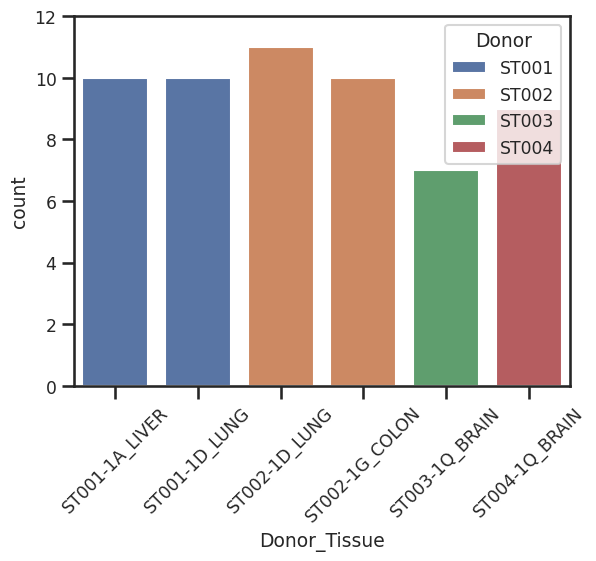

In [24]:
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

counts[['Donor', 'Tissue']] = counts['Donor_Tissue'].str.split('-', expand=True)

g = sns.barplot(
    data=counts,
    x="Donor_Tissue",
    y="count",
    hue="Donor",
 #   bins=6,
 #   alpha=0.6,
)
plt.ylim(0,12)
#sns.move_legend(g, "center right", bbox_to_anchor=(1.3,0.5))
plt.xticks(rotation=45)
plt.show()



In [67]:
## circos plot 

from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_eukaryote_example_dataset

mt_length = 16569 
scale_factor=200000
input_file="/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/ST001-1A_LIVER-ont-bcm/numts/ST001-1A_LIVER-ont-bcm.numts.INS.blast.mtDNA.txt"
bed_file = "/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/circos.bed"

# Initialize Circos with space between chromosomes
circos = Circos.initialize_from_bed(bed_file, space=2)

# Assign Colors
chr_names = [s.name for s in circos.sectors]

#ColorCycler.set_cmap("gist_rainbow")
colors = ColorCycler.get_color_list(len(chr_names))

colors = list(plt.cm.tab20(np.linspace(0, 1, 20)))  # 20 colors
colors += list(plt.cm.tab20b(np.linspace(0, 1, 4)))  # 4 more colors
chr_name2color = {name: color for name, color in zip(chr_names, colors)}
#chr_name2color = {name: colors[i % 24] for i, name in enumerate(chr_names)}

#---- Label chromosomes and draw outer track ----
tick_interval = 2000
positions = [i * scale_factor for i in range(0, mt_length, tick_interval)]
labels = [f"{i//1000}k" for i in range(0, mt_length, tick_interval)]

for sector in circos.sectors:
    label = sector.name.replace("chr", "")
    sector.text(label, size=10)
    track = sector.add_track((95, 100))

    # Add coordinate labels only for chrMT
    if sector.name in ["chrM", "chrMT"]:
        track.xticks(
            positions,
            labels=labels,
            outer=True,
            label_orientation="vertical"
        )
        track.axis(fc="#6baed6", lw=1)
    else:
        color = chr_name2color.get(sector.name, "gray")
        track.axis(fc=color, lw=1)

collapsed_numt_df['mstart_rep'] = collapsed_numt_df['mstart_rep'].astype(int)
collapsed_numt_df['mend_rep'] = collapsed_numt_df['mend_rep'].astype(int)

# ---- Plot each link ----
for _, row in collapsed_numt_df.iterrows():
    region_mt = ("chrMT", int(row["mstart_rep"]*scale_factor), int(row["mend_rep"]*scale_factor))
    region_nuc = (row["nchr"], int(row["npos_rep"]), int(row["npos_rep"] + 1))
    # Color based on nuclear chromosome
   # color = chr_name2color.get(row["nchr"], "blue")
    color = cmap(norm(row["freq"]))

    circos.link(region_mt, region_nuc, color=color, alpha=0.7, lw=0.5)

# ---- Save ----
circos.savefig('circos.png', dpi=300)


In [ ]:
# # example: count unique samples per NUMT_ID
# freq_df = (
#     collapsed_numt_df.groupby("numt_long")["Donor_Tissue"]
#       .nunique()
#       .reset_index(name="freq")
# )

# collapsed_numt_df = collapsed_numt_df.merge(freq_df, on="numt_long")

import matplotlib.pyplot as plt
from matplotlib import cm, colors

norm = colors.Normalize(
    vmin=collapsed_numt_df["freq"].min(),
    vmax=collapsed_numt_df["freq"].max()
)

cmap = cm.viridis   # blue → green → yellow


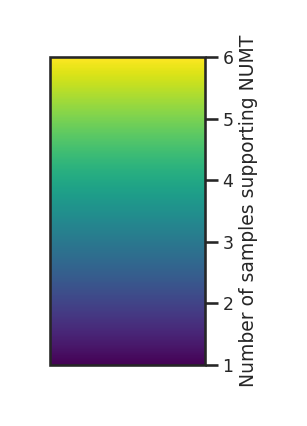

In [60]:
import matplotlib.pyplot as plt
from matplotlib import cm

# define colormap and normalization
cmap = cm.viridis
norm = plt.Normalize(vmin=collapsed_numt_df["freq"].min(),
                     vmax=collapsed_numt_df["freq"].max())

# create a dummy figure just for the colorbar
fig, ax = plt.subplots(figsize=(2, 4))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax)
cbar.set_label("Number of samples supporting NUMT")
fig.savefig("colorbar.png", dpi=300, bbox_inches="tight")
